# Understanding Why Customers Leave

## A Customer Churn Analysis Using Python

### About This Project

I created this project to practice data analysis using Python and explore a customer churn dataset.

Instead of jumping directly into charts, I wanted to understand who the customers are, how they use the service, and whether certain behaviours seem to be connected with churn.

The dataset contains **100,000 customer records** and **9 columns**. The target variable is **Churn**, which shows whether a customer stayed or left.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("synthetic_customer_churn_100k.csv")


## 1. Understanding The Dataset

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()


Dataset Shape: (100000, 9)

Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges', 'Churn']


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


### Initial Observation

I can see that the dataset contains customer demographics and account-related information such as age, tenure, contract type, monthly charges, payment method, and churn status.

Before exploring churn patterns, I wanted to make sure the data looked complete and was stored correctly.


## 2. Missing Value Analysis

In [5]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

### Observation

I checked for missing values before starting the analysis.
Missing data can affect results.


## 3. Descriptive Statistics

In [ ]:
df.describe()

### Observation

I noticed that customer tenure and monthly charges vary quite a lot, which makes them interesting variables to explore later.


## 4. What Percentage Of Customers Are Churning?

Churn
No     66.86
Yes    33.14
Name: proportion, dtype: float64


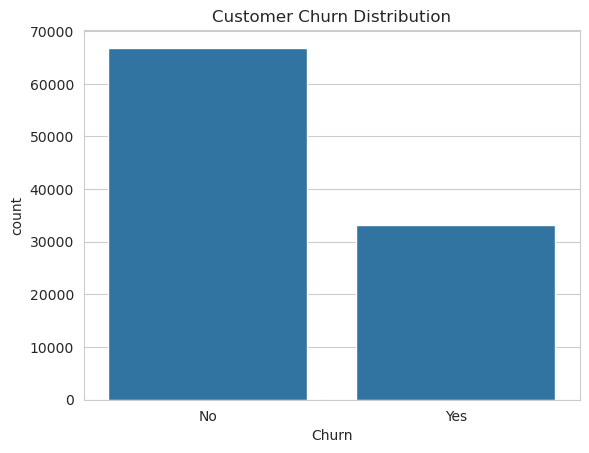

In [6]:
churn_rate = (df['Churn'].value_counts(normalize=True) * 100).round(2)

print(churn_rate)

sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()


### Observation

The overall churn rate is approximately **33.14%**.

Most customers stayed with the company, but a significant number also left. This makes churn an important problem worth investigating.


## 5. Age Distribution

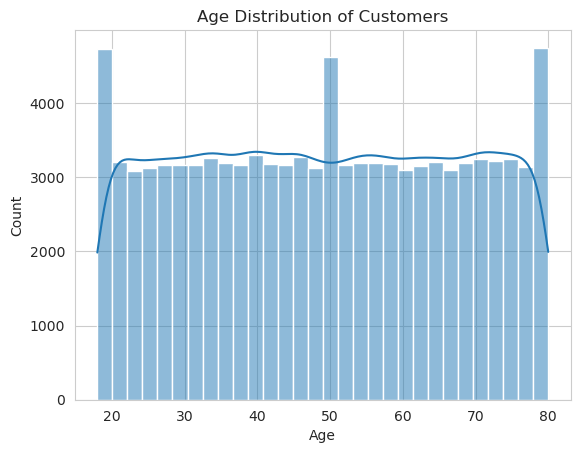

In [7]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.show()


### Observation

I explored the age distribution to understand the customer base.

The customers are spread across different age groups, which suggests that the company serves a broad range of customers rather than focusing on a single age segment.


## 6. Feature Engineering

In [8]:
# Average monthly spend based on total charges and tenure

df['AvgSpendPerMonth'] = df['TotalCharges'] / (df['Tenure'] + 1)

df[['AvgSpendPerMonth']].head()


,AvgSpendPerMonth
0,145.681594
1,20.811515
2,48.898182
3,103.914783
4,128.750545


### Why Create This Feature?

I wanted to create a simple feature that gives another view of customer spending behaviour.

This is not required for the analysis, but it is a useful exercise for practicing feature engineering.


## 7. Tenure vs Churn

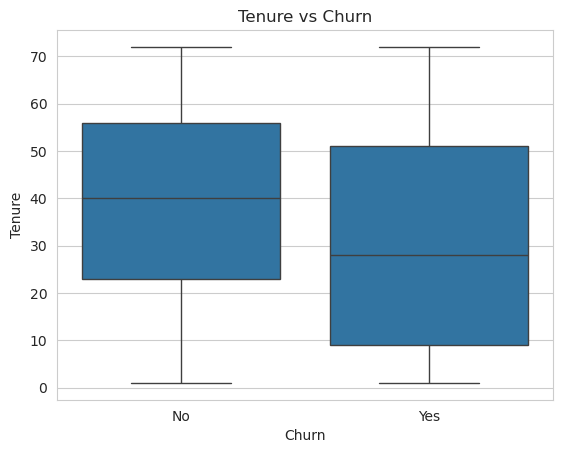

Churn
No     39.321796
Yes    30.889784
Name: Tenure, dtype: float64

In [9]:
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title('Tenure vs Churn')
plt.show()

df.groupby('Churn')['Tenure'].mean()


### Observation

I noticed that customers who churned generally had lower tenure compared to customers who stayed.

One possible reason could be that newer customers have not yet developed long-term loyalty to the service.


## 8. Monthly Charges vs Churn

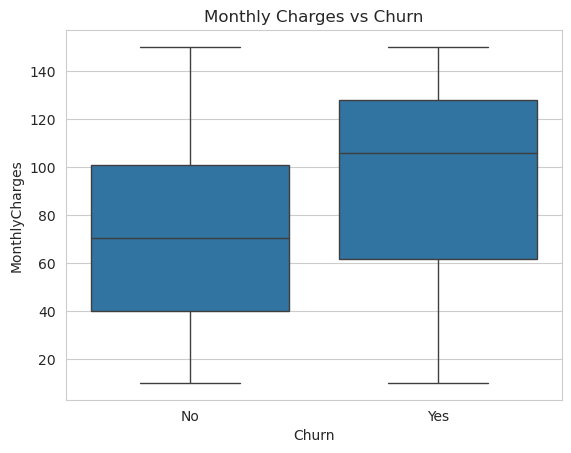

Churn
No     72.845838
Yes    94.355298
Name: MonthlyCharges, dtype: float64

In [10]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

df.groupby('Churn')['MonthlyCharges'].mean()


### Observation

Customers who churned appear to have higher monthly charges on average.

This suggests that pricing or perceived value may play a role in customer retention.


## 9. Contract Type Analysis

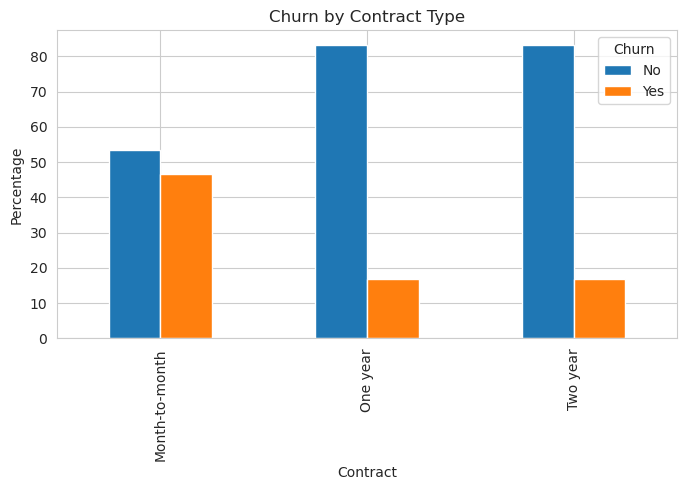

Churn,No,Yes
Contract,,
Month-to-month,53.442593,46.557407
One year,83.250861,16.749139
Two year,83.121469,16.878531


In [11]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(kind='bar', figsize=(8,4))
plt.title('Churn by Contract Type')
plt.ylabel('Percentage')
plt.show()

contract_churn


### Observation

I noticed that month-to-month contracts have a much higher churn rate than one-year and two-year contracts.

This suggests that customers with longer commitments are generally more likely to stay.


## 10. Payment Method Analysis

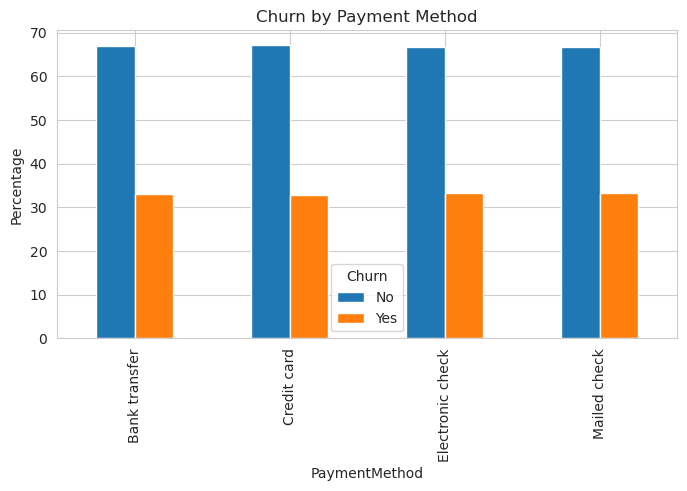

Churn,No,Yes
PaymentMethod,,
Bank transfer,66.995719,33.004281
Credit card,67.207468,32.792532
Electronic check,66.711567,33.288433
Mailed check,66.666667,33.333333


In [12]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

payment_churn.plot(kind='bar', figsize=(8,4))
plt.title('Churn by Payment Method')
plt.ylabel('Percentage')
plt.show()

payment_churn


### Observation

There are some differences between payment methods, although the differences are smaller than those seen for contract type.

This suggests that payment method may have some relationship with churn, but it does not appear to be the strongest factor.


## 11. Correlation Analysis

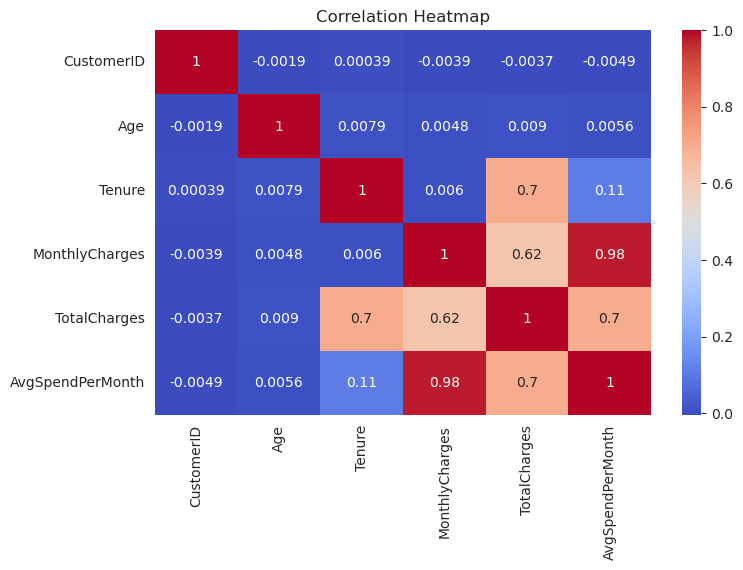

In [13]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### Observation

The heatmap helped me explore relationships between numeric variables.

While correlation does not prove causation, it provides a useful starting point for identifying patterns in the data.


# Key Findings

1. Customers with lower tenure were more likely to churn.
2. Month-to-month contracts showed much higher churn than longer contracts.
3. Customers paying higher monthly charges appeared more likely to leave.
4. Long-term customers were generally more likely to stay.
5. Payment method showed some variation, but contract type appeared to be a stronger factor.


# Recommendations

### Improve onboarding for new customers

Customers with lower tenure appeared more likely to churn.

### Encourage longer-term contracts

Customers with one-year and two-year contracts were generally more likely to stay.

### Review higher-priced plans

Higher monthly charges appeared to be associated with higher churn.

### Create targeted retention campaigns

Customers showing common churn characteristics could be contacted before they decide to leave.


# What I Learned

Through this project, I learned how to:

- Load and explore datasets using Pandas
- Check data quality
- Create visualizations with Matplotlib and Seaborn
- Perform exploratory data analysis
- Identify patterns related to customer churn
- Communicate findings in a clear and simple way

This project helped me gain more confidence working with real-world datasets.


# Final Conclusion

In this project, I explored customer churn data to understand factors that may influence customer retention.

Based on the analysis, tenure, contract type, and monthly charges appeared to have a relationship with churn. Customers with shorter tenure, month-to-month contracts, and higher monthly charges were more likely to leave.

Overall, this project helped me strengthen my Python, Pandas, visualization, and exploratory data analysis skills while learning how data can be used to support business decisions.
